# Эксперимент: Обзор EDA host-слоя

**Цель.** Зафиксировать базовое состояние host-layer данных перед обучением и калибровкой модели.

**Исследовательские вопросы.**
- Как распределены объекты `M/K/G/F` по слоям `ALL`, `DWARFS`, `EVOLVED`?
- Есть ли явные аномалии по пропускам, радиусам и межклассовым агрегатам?
- Насколько базовые графики подтверждают физическое разделение `DWARFS` и `EVOLVED`?

**Что считается готовым результатом.**
- Загружены все базовые обучающие слои и `A/B/O` референсный слой.
- Построены компактные контрольные таблицы и ключевые графики.
- Сформированы артефакты, на которые можно ссылаться в тексте ВКР.


## Источники данных и артефакты

Этот ноутбук не содержит исследовательской логики внутри себя. Он использует готовые модули из `analysis.host_eda`.

**Входные источники.**
- `lab.v_nasa_gaia_train_classified`
- `lab.v_nasa_gaia_train_dwarfs`
- `lab.v_nasa_gaia_train_evolved`
- `lab.v_gaia_ref_abo_training`

**Выходные артефакты.**
- `data/eda/host/evolved_stars_snapshot.csv`
- `data/eda/host/abo_top20_by_teff.csv`
- PNG-файлы в `data/eda/host/plots/`


In [14]:
from __future__ import annotations

from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / 'src').exists():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError('Repo root with src/ not found.')
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from IPython.display import Image, display
import pandas as pd

from analysis.host_eda.constants import ABO_TOP20_PATH, EVOLVED_SNAPSHOT_PATH, PLOTS_DIR
from analysis.host_eda.data import load_abo_ref, load_all_mkgf, load_dwarfs_mkgf, load_evolved_mkgf
from analysis.host_eda.exports import save_frame
from analysis.host_eda.plots import (
    plot_class_counts,
    plot_feature_histograms,
    plot_logg_radius_with_threshold,
    plot_scatter_layers,
    set_default_theme,
)
from analysis.host_eda.stats import build_group_stats, top_by_radius, top_by_teff

set_default_theme()
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)


## План анализа

1. Загрузить четыре слоя данных и сверить размеры выборок.
2. Проверить пропуски и агрегаты по спектральным классам.
3. Зафиксировать крайние объекты и сохранить tabular-артефакты.
4. Построить минимальный набор графиков для визуальной проверки физической структуры.


In [15]:
df_all = load_all_mkgf()
df_dwarfs = load_dwarfs_mkgf()
df_evolved = load_evolved_mkgf()
df_abo = load_abo_ref()

summary = pd.DataFrame(
    [
        {'layer': 'ALL MKGF', 'rows': len(df_all), 'classes': sorted(df_all['spec_class'].unique().tolist())},
        {'layer': 'DWARFS', 'rows': len(df_dwarfs), 'classes': sorted(df_dwarfs['spec_class'].unique().tolist())},
        {'layer': 'EVOLVED', 'rows': len(df_evolved), 'classes': sorted(df_evolved['spec_class'].unique().tolist())},
        {'layer': 'A/B/O REF', 'rows': len(df_abo), 'classes': sorted(df_abo['spec_class'].unique().tolist())},
    ]
)
summary


,layer,rows,classes
0,ALL MKGF,3713,"[F, G, K, M]"
1,DWARFS,3394,"[F, G, K, M]"
2,EVOLVED,319,"[F, G, K, M]"
3,A/B/O REF,9000,"[A, B, O]"


## Проверка качества данных

Здесь фиксируются два базовых сигнала:
- есть ли проблемы с полнотой данных;
- насколько агрегаты по классам соответствуют физическим ожиданиям.


In [16]:
null_report = df_all.isnull().sum().to_frame(name='null_count')
null_report


,null_count
spec_class,0
teff_gspphot,0
logg_gspphot,0
radius_gspphot,0


In [17]:
class_stats = build_group_stats(df_all)
class_stats


teff_gspphot                                   logg_gspphot                           radius_gspphot                           
                   mean         std        min        max         mean       std     min     max           mean       std     min      max
spec_class                                                                                                                                
F           6250.130146  262.952603  6000.5503  7493.4976     4.143905  0.136642  3.6190  4.5509       1.539561  0.340151  0.8540   3.1978
G           5609.744986  204.881940  5200.2637  5999.4700     4.307398  0.198659  2.6701  4.7872       1.211231  0.566934  0.5073  13.3763
K           4793.450663  273.731679  4003.0696  5198.5396     4.330783  0.594543  1.2817  4.8192       1.897704  4.422914  0.4755  84.6923
M           3483.076564  283.747524  2886.4172  3990.4140     4.529760  0.311829  3.9365  5.1591       0.522030  0.179244  0.1554   1.3791

## Крайние объекты и контрольные выгрузки

Эти таблицы полезны для ручной проверки и для ссылок в тексте работы.


In [18]:
print('ТОП-20 объектов ALL MKGF по радиусу')
display(top_by_radius(df_all))

print('ТОП-20 объектов A/B/O REF по температуре')
display(top_by_teff(df_abo))

save_frame(df_evolved, EVOLVED_SNAPSHOT_PATH)
save_frame(top_by_teff(df_abo), ABO_TOP20_PATH)
print('Сохранено:', EVOLVED_SNAPSHOT_PATH)
print('Сохранено:', ABO_TOP20_PATH)


ТОП-20 объектов ALL MKGF по радиусу


,spec_class,teff_gspphot,logg_gspphot,radius_gspphot
132,K,4649.5723,1.2817,84.6923
447,K,4190.4950,1.3584,41.3697
373,K,4436.9590,1.7978,39.0489
37,K,4705.5850,2.0849,28.4643
2418,K,4862.4870,2.1920,26.9617
271,K,4687.6167,2.1565,26.8125
2467,K,4629.4053,2.1448,26.2721
304,K,4723.3470,2.2078,24.9307
2868,K,4430.6770,1.9725,22.0147
107,K,4815.0940,2.2973,21.8685


ТОП-20 объектов A/B/O REF по температуре


,spec_class,teff_gspphot,logg_gspphot,radius_gspphot
6201,O,41342.062,4.0511,8.6314
8785,O,41255.184,4.0848,8.1100
7912,O,40819.574,4.1214,7.4962
6795,O,40769.990,4.1287,7.3900
7214,O,40489.707,4.0826,7.9138
8369,O,40202.832,4.1042,7.5536
7857,O,40109.934,4.1523,6.9682
6753,O,40070.098,4.1522,6.9475
8749,O,39972.285,3.9665,9.6408
7663,O,39933.285,3.8935,10.8631


Сохранено: data/eda/host/evolved_stars_snapshot.csv
Сохранено: data/eda/host/abo_top20_by_teff.csv


## Ключевые визуализации

Ноутбук вызывает уже готовые функции построения графиков. Это важно для воспроизводимости: графики в ноутбуке и в offline EDA строятся одним и тем же кодом.


/Users/evgeniikuznetsov/Desktop/dspro-vkr/analysis/host_eda/exports.py:22: UserWarning: Glyph 9737 (\N{SUN}) missing from font(s) Arial.
  figure_any.tight_layout()
/Users/evgeniikuznetsov/Desktop/dspro-vkr/analysis/host_eda/exports.py:23: UserWarning: Glyph 9737 (\N{SUN}) missing from font(s) Arial.
  figure_any.savefig(path, dpi=160)
/Users/evgeniikuznetsov/Desktop/dspro-vkr/analysis/host_eda/exports.py:22: UserWarning: Glyph 9737 (\N{SUN}) missing from font(s) Arial.
  figure_any.tight_layout()
/Users/evgeniikuznetsov/Desktop/dspro-vkr/analysis/host_eda/exports.py:23: UserWarning: Glyph 9737 (\N{SUN}) missing from font(s) Arial.
  figure_any.savefig(path, dpi=160)


data/eda/host/plots/nb_all_class_counts.png


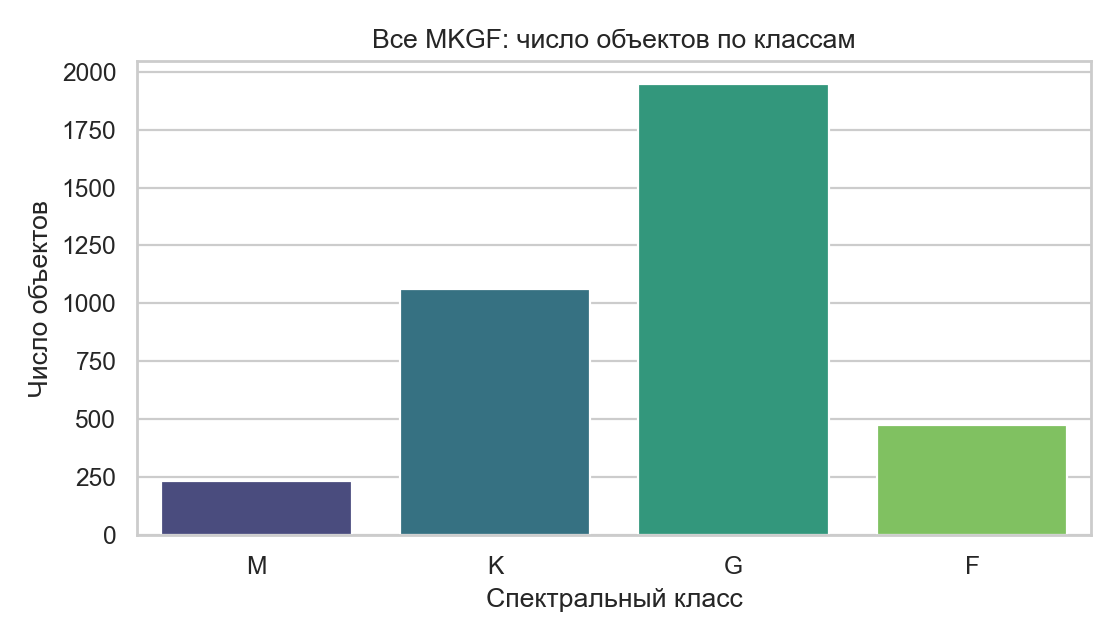

data/eda/host/plots/nb_dwarfs_teff_gspphot_hist.png


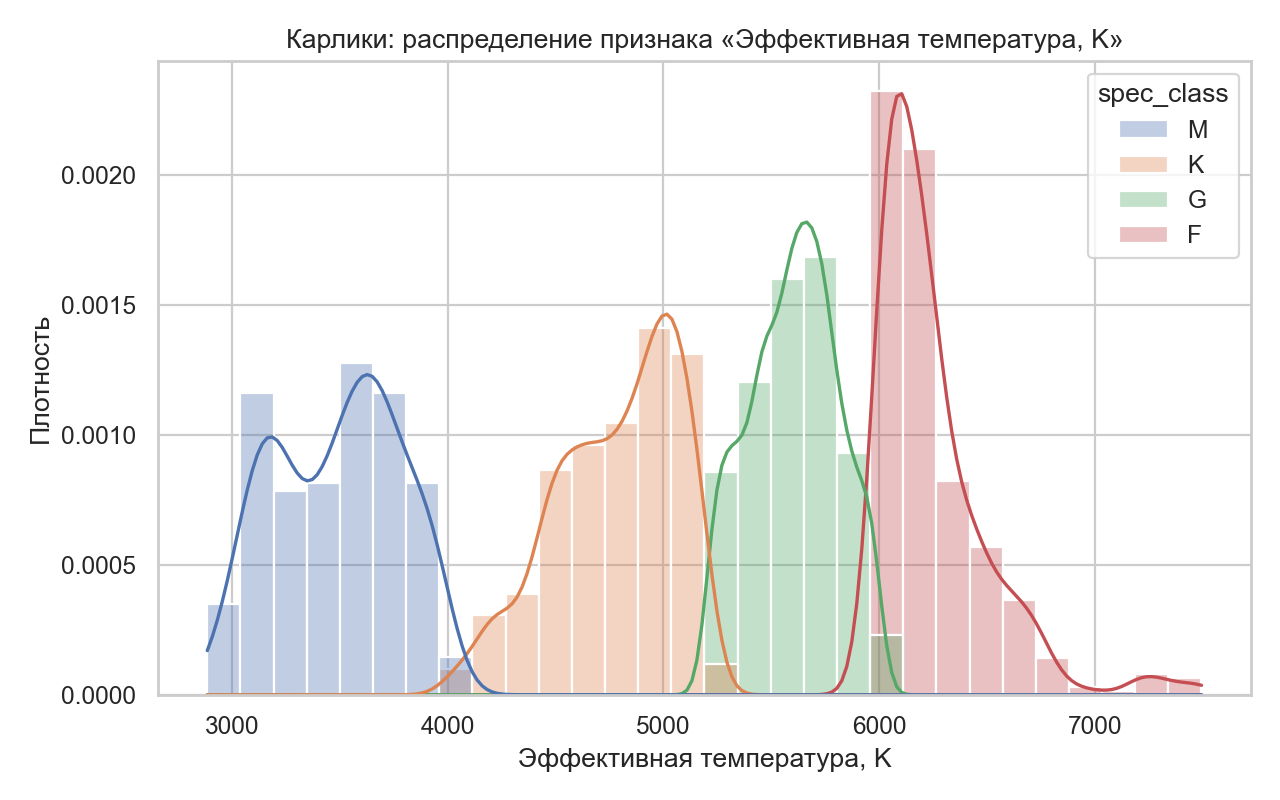

data/eda/host/plots/layers_teff_vs_radius_scatter.png


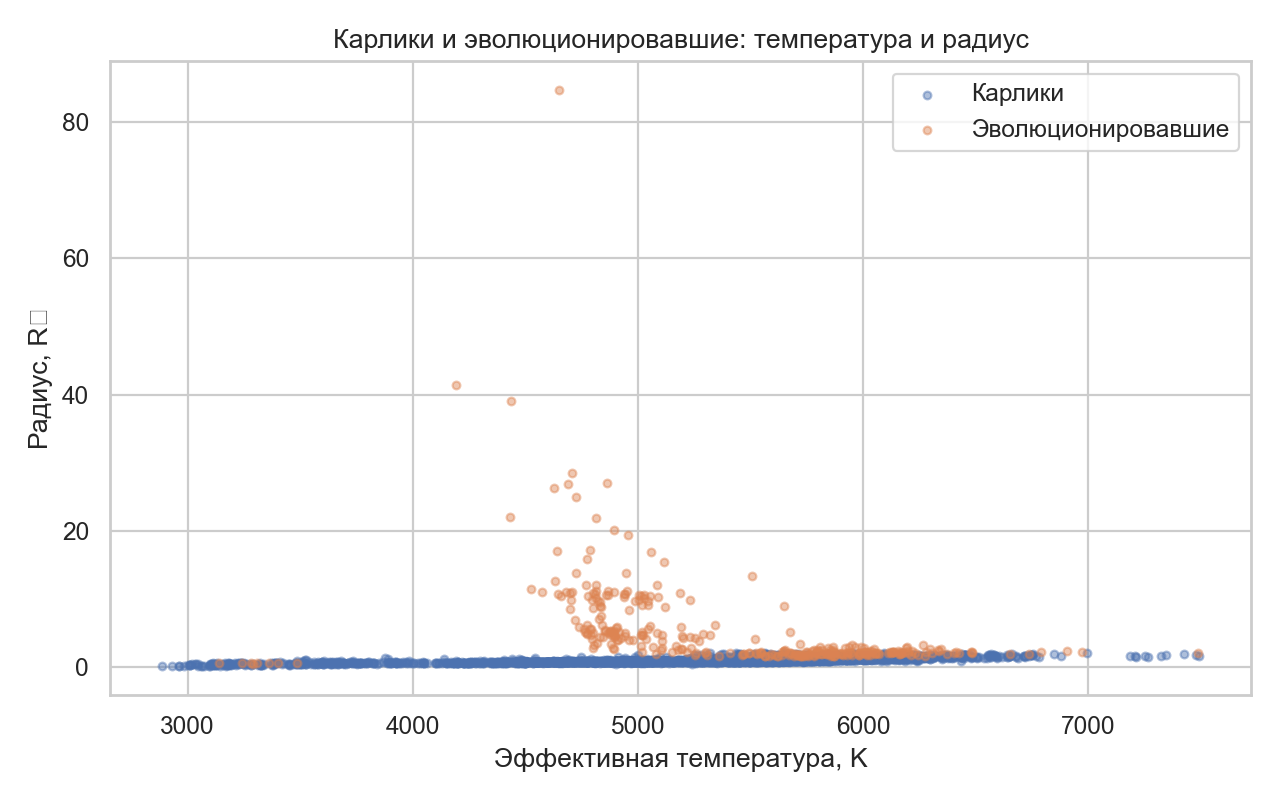

data/eda/host/plots/all_logg_vs_radius_with_threshold.png


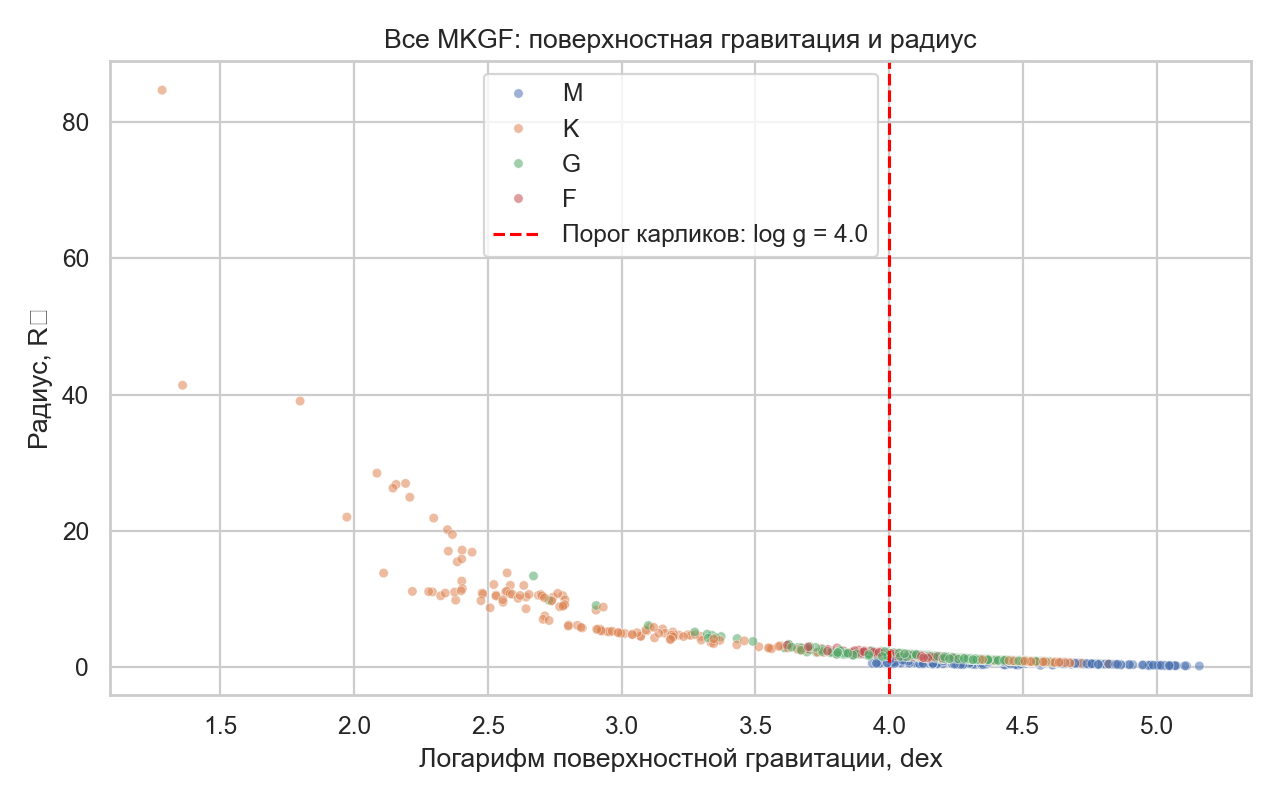

In [19]:
plot_class_counts(df_all, title='Все MKGF: число объектов по классам', filename='nb_all_class_counts.png')
plot_feature_histograms(df_dwarfs, filename_prefix='nb_dwarfs', title_prefix='Карлики')
plot_scatter_layers(df_dwarfs, df_evolved)
plot_logg_radius_with_threshold(df_all)

for filename in [
    'nb_all_class_counts.png',
    'nb_dwarfs_teff_gspphot_hist.png',
    'layers_teff_vs_radius_scatter.png',
    'all_logg_vs_radius_with_threshold.png',
]:
    path = PLOTS_DIR / filename
    print(path)
    display(Image(filename=path))


## Интерпретация

При чтении результатов стоит проверить три вещи:
- не доминируют ли `EVOLVED` среди объектов с наибольшим радиусом;
- расходятся ли `DWARFS` и `EVOLVED` в проекции `Teff × Radius`;
- нет ли классов, где агрегаты выглядят физически нестабильными или противоречивыми.

Если эти условия выполняются, базовый host-layer можно считать пригодным для следующего contrastive-анализа.


## Следующий шаг

После этого логично перейти к контрастивному анализу и проверить разделимость `host` и `field` внутри физических веток `M/K/G/F`.
